In [1]:
# Folder path 
path = "/home/shashank/Documents/UniBonn/Sem4/ThesisPrep/pyslam/data/TUM/person_tracking/rgb_jpg/"

import os
import shutil
import tempfile

def create_temp_symlink_folder(dataset_images_path_dir, start_idx, end_idx, temp_folder_name="sam2_temp_symlinks"):
    """
    Creates a clean temporary folder with symlinks to selected images from a dataset directory.

    Args:
        dataset_images_path_dir (str): Path to the folder containing RGB images.
        start_idx (int): Start frame index (inclusive).
        end_idx (int): End frame index (exclusive).
        temp_folder_name (str): Name for the temp folder (under /tmp). Default: 'sam2_temp_symlinks'.

    Returns:
        str: Path to the temporary folder with symlinks.
    """
    # Create sorted list of image filenames
    images_paths_ordered = sorted(os.listdir(dataset_images_path_dir))
    print(f"Ordered images: {images_paths_ordered}")

    # Validate indices
    if start_idx < 0 or end_idx > len(images_paths_ordered):
        raise IndexError(f"Frame range [{start_idx}, {end_idx}) is out of bounds for {len(images_paths_ordered)} images.")

    # Create or clean up temp folder
    temp_root = os.path.join(tempfile.gettempdir(), temp_folder_name)
    if os.path.exists(temp_root):
        shutil.rmtree(temp_root)
    os.makedirs(temp_root)

    # Create symlinks
    for fname in images_paths_ordered[start_idx:end_idx]: # Includes the start index, excludes the end index
        src_path = os.path.join(dataset_images_path_dir, fname)
        dst_path = os.path.join(temp_root, fname)
        if not os.path.exists(src_path):
            raise FileNotFoundError(f"Source image not found: {src_path}")
        os.symlink(os.path.abspath(src_path), dst_path)

    return temp_root

def create_temp_symlink_folder_from_list_of_ids(dataset_images_path_dir, idxs, temp_folder_name="sam2_temp_symlinks"):
    """
    Creates a temporary folder with symlinks to RGB images.
    Args:
        dataset_images_path_dir (str): Path to the folder containing RGB images.
        idxs (list): List of image indices to include in the temp folder.
        temp_folder_name (str): Name for the temp folder (under /tmp). Default: 'sam2_temp_symlinks'.
    Returns:
        str: Path to the temporary folder with symlinks.
    """
    # Create sorted list of image filenames
    images_paths_ordered = sorted(os.listdir(dataset_images_path_dir))
    print(f"Ordered images: {images_paths_ordered}")


    # Validate indices
    if any(idx < 0 or idx >= len(images_paths_ordered) for idx in idxs):
        raise IndexError(f"Frame indices {idxs} are out of bounds for {len(images_paths_ordered)} images.")

    # Create or clean up temp folder
    temp_root = os.path.join(tempfile.gettempdir(), temp_folder_name)
    if os.path.exists(temp_root):
        shutil.rmtree(temp_root)
    os.makedirs(temp_root)

    # Create symlinks
    for idx in idxs:
        fname = images_paths_ordered[idx]
        src_path = os.path.join(dataset_images_path_dir, fname)
        dst_path = os.path.join(temp_root, fname)
        if not os.path.exists(src_path):
            raise FileNotFoundError(f"Source image not found: {src_path}")
        os.symlink(os.path.abspath(src_path), dst_path)

    return temp_root

def get_sam2_streamer_frames_from_sym_link(temp_folder):
    """
    initial_frames = {
    0: "/path/to/frame001.jpg", 
    1: "/path/to/frame002.jpg", 
    2: "/path/to/frame003.jpg"
}
    """
    initial_frames = {}
    for idx, fname in enumerate(sorted(os.listdir(temp_folder))):
        src_path = os.path.join(temp_folder, fname)
        real_path = os.path.realpath(src_path)
        initial_frames[idx] = real_path
    return initial_frames

def initialize_sam2_streamer_frames_prompts(frames):
    """
   initial_prompts = {
    0: {  # Frame index
        1: {  # Object ID
            "points": np.array([[210, 350]], dtype=np.float32),
            "labels": np.array([1], dtype=np.int32)
        }
    }
}
    """
    initial_prompts = {}
    for idx, frame in frames.items():
        initial_prompts[idx] = {}
    return initial_prompts




if __name__ == "__main__":
    # Example usage
    start_idx = 0
    end_idx = 10
    temp_folder = create_temp_symlink_folder(path, start_idx, end_idx)
    print(f"Temporary folder created at: {temp_folder}")
    print(f"Sorted images in temp folder: {sorted(os.listdir(temp_folder))}")

    # Example usage with list of indices
    idxs = [0, 2, 4, 6, 8]
    temp_folder_from_list = create_temp_symlink_folder_from_list_of_ids(path, idxs)
    print(f"Temporary folder created from list of indices at: {temp_folder_from_list}")
    print(f"Sorted images in temp folder from list: {sorted(os.listdir(temp_folder_from_list))}")

Ordered images: ['00000.jpg', '00001.jpg', '00002.jpg', '00003.jpg', '00004.jpg', '00005.jpg', '00006.jpg', '00007.jpg', '00008.jpg', '00009.jpg', '00010.jpg', '00011.jpg', '00012.jpg', '00013.jpg', '00014.jpg', '00015.jpg', '00016.jpg', '00017.jpg', '00018.jpg', '00019.jpg', '00020.jpg', '00021.jpg', '00022.jpg', '00023.jpg', '00024.jpg', '00025.jpg', '00026.jpg', '00027.jpg', '00028.jpg', '00029.jpg', '00030.jpg', '00031.jpg', '00032.jpg', '00033.jpg', '00034.jpg', '00035.jpg', '00036.jpg', '00037.jpg', '00038.jpg', '00039.jpg', '00040.jpg', '00041.jpg', '00042.jpg', '00043.jpg', '00044.jpg', '00045.jpg', '00046.jpg', '00047.jpg', '00048.jpg', '00049.jpg', '00050.jpg', '00051.jpg', '00052.jpg', '00053.jpg', '00054.jpg', '00055.jpg', '00056.jpg', '00057.jpg', '00058.jpg', '00059.jpg', '00060.jpg', '00061.jpg', '00062.jpg', '00063.jpg', '00064.jpg', '00065.jpg', '00066.jpg', '00067.jpg', '00068.jpg', '00069.jpg', '00070.jpg', '00071.jpg', '00072.jpg', '00073.jpg', '00074.jpg', '00075.j

In [2]:
# Load first 10 images in SAM2 and propagate and visualize the images
"""
# Initialize the streamer
streamer = SAM2SymlinkStreamer(predictor, "./symlink_frames")

# Initial run with first set of frames and prompts
initial_frames = {
    0: "/path/to/frame001.jpg", 
    1: "/path/to/frame002.jpg", 
    2: "/path/to/frame003.jpg"
}

# Add initial prompts for object 1 on frame 0
initial_prompts = {
    0: {  # Frame index
        1: {  # Object ID
            "points": np.array([[210, 350]], dtype=np.float32),
            "labels": np.array([1], dtype=np.int32)
        }
    }
}

results = streamer.update_symlinks(initial_frames, initial_prompts)

# Later, update with more frames, keeping some old ones
updated_frames = {
    0: "/path/to/frame001.jpg",  # Keep this frame
    2: "/path/to/frame003.jpg",  # Keep this frame
    3: "/path/to/frame004.jpg",  # Add new frame
    4: "/path/to/frame005.jpg"   # Add new frame
}

# Maybe add prompts for frame 3
new_prompts = {
    3: {  # Frame index
        1: {  # Object ID (same object as before)
            "points": np.array([[250, 300]], dtype=np.float32),
            "labels": np.array([1], dtype=np.int32)
        }
    }
}

# Update and get new results
updated_results = streamer.update_symlinks(updated_frames, new_prompts)

"""
from sam2_streaming import SAM2SymlinkStreamer

In [3]:

import os
# if using Apple MPS, fall back to CPU for unsupported ops
os.environ["PYTORCH_ENABLE_MPS_FALLBACK"] = "1"
import numpy as np
import torch
import matplotlib.pyplot as plt
from PIL import Image

In [4]:
# select the device for computation
if torch.cuda.is_available():
    device = torch.device("cuda")
elif torch.backends.mps.is_available():
    device = torch.device("mps")
else:
    device = torch.device("cpu")
print(f"using device: {device}")

if device.type == "cuda":
    # use bfloat16 for the entire notebook
    torch.autocast("cuda", dtype=torch.bfloat16).__enter__()
    # turn on tfloat32 for Ampere GPUs (https://pytorch.org/docs/stable/notes/cuda.html#tensorfloat-32-tf32-on-ampere-devices)
    if torch.cuda.get_device_properties(0).major >= 8:
        torch.backends.cuda.matmul.allow_tf32 = True
        torch.backends.cudnn.allow_tf32 = True
elif device.type == "mps":
    print(
        "\nSupport for MPS devices is preliminary. SAM 2 is trained with CUDA and might "
        "give numerically different outputs and sometimes degraded performance on MPS. "
        "See e.g. https://github.com/pytorch/pytorch/issues/84936 for a discussion."
    )

using device: cuda


In [5]:
import torch
print(torch.cuda.is_available())
print(torch.cuda.device_count())
print(torch.cuda.current_device())
print(torch.cuda.get_device_name(torch.cuda.current_device()))


True
1
0
NVIDIA GeForce RTX 3060 Laptop GPU


In [6]:
from sam2.build_sam import build_sam2_video_predictor

sam2_checkpoint = "../checkpoints/sam2.1_hiera_tiny.pt"
model_cfg = "configs/sam2.1/sam2.1_hiera_t.yaml"

predictor = build_sam2_video_predictor(model_cfg, sam2_checkpoint, device=device)

In [7]:
streamer = SAM2SymlinkStreamer(predictor, temp_folder_from_list)

# Initial 10 frames
start_idx = 0
end_idx = 10
temp_folder = create_temp_symlink_folder(path, start_idx, end_idx)
initial_frames = get_sam2_streamer_frames_from_sym_link(temp_folder)
print(f"Initial frames: {initial_frames}")
initial_prompts = initialize_sam2_streamer_frames_prompts(initial_frames)
print(f"Initial prompts: {initial_prompts}")
# Add initial prompts for object 1 on frame 0
initial_prompts[0][1] = {
    "points": np.array([[810, 300]], dtype=np.float32),
    "labels": np.array([1], dtype=np.int32)
}
print(f"Initial prompts after adding: {initial_prompts}")



Ordered images: ['00000.jpg', '00001.jpg', '00002.jpg', '00003.jpg', '00004.jpg', '00005.jpg', '00006.jpg', '00007.jpg', '00008.jpg', '00009.jpg', '00010.jpg', '00011.jpg', '00012.jpg', '00013.jpg', '00014.jpg', '00015.jpg', '00016.jpg', '00017.jpg', '00018.jpg', '00019.jpg', '00020.jpg', '00021.jpg', '00022.jpg', '00023.jpg', '00024.jpg', '00025.jpg', '00026.jpg', '00027.jpg', '00028.jpg', '00029.jpg', '00030.jpg', '00031.jpg', '00032.jpg', '00033.jpg', '00034.jpg', '00035.jpg', '00036.jpg', '00037.jpg', '00038.jpg', '00039.jpg', '00040.jpg', '00041.jpg', '00042.jpg', '00043.jpg', '00044.jpg', '00045.jpg', '00046.jpg', '00047.jpg', '00048.jpg', '00049.jpg', '00050.jpg', '00051.jpg', '00052.jpg', '00053.jpg', '00054.jpg', '00055.jpg', '00056.jpg', '00057.jpg', '00058.jpg', '00059.jpg', '00060.jpg', '00061.jpg', '00062.jpg', '00063.jpg', '00064.jpg', '00065.jpg', '00066.jpg', '00067.jpg', '00068.jpg', '00069.jpg', '00070.jpg', '00071.jpg', '00072.jpg', '00073.jpg', '00074.jpg', '00075.j

In [8]:
results = streamer.update_symlinks(initial_frames, initial_prompts)
print(f"Results after initial update: {results}")

Self.inference_state is None, initializing...


frame loading (JPEG): 100%|██████████| 10/10 [00:00<00:00, 20.28it/s]
/home/shashank/Documents/UniBonn/thesis/pyslam/thirdparty/sam2/sam2/sam2_video_predictor.py:786: UserWarning: cannot import name '_C' from 'sam2' (/home/shashank/Documents/UniBonn/thesis/pyslam/thirdparty/sam2/sam2/__init__.py)

Skipping the post-processing step due to the error above. You can still use SAM 2 and it's OK to ignore the error above, although some post-processing functionality may be limited (which doesn't affect the results in most cases; see https://github.com/facebookresearch/sam2/blob/main/INSTALL.md).
  pred_masks_gpu = fill_holes_in_mask_scores(
propagate in video: 100%|██████████| 10/10 [00:00<00:00, 10.13it/s]

Results after initial update: {0: {1: array([[[False, False, False, ..., False, False, False],
        [False, False, False, ..., False, False, False],
        [False, False, False, ..., False, False, False],
        ...,
        [False, False, False, ..., False, False, False],
        [False, False, False, ..., False, False, False],
        [False, False, False, ..., False, False, False]]])}, 1: {1: array([[[False, False, False, ..., False, False, False],
        [False, False, False, ..., False, False, False],
        [False, False, False, ..., False, False, False],
        ...,
        [False, False, False, ..., False, False, False],
        [False, False, False, ..., False, False, False],
        [False, False, False, ..., False, False, False]]])}, 2: {1: array([[[False, False, False, ..., False, False, False],
        [False, False, False, ..., False, False, False],
        [False, False, False, ..., False, False, False],
        ...,
        [False, False, False, ..., False, Fals

In [9]:

import cv2
def sam2_logits_to_masks(out_mask_logits, img, threshold=0.0):
    """
    Convert SAM2 output logits to a list of binary masks matching image shape.
    
    Args:
        out_mask_logits: Output tensor from SAM2 model (shape [N, H, W])
        img: Reference image to match shape
        threshold: Value to threshold logits at (default: 0.0)
    
    Returns:
        List of binary masks as np.uint8 arrays with shape matching img's H,W (single channel)
    """
    masks = []
    
    # Handle case where out_mask_logits is None
    if out_mask_logits is None:
        return masks
    
    # Check if img has valid dimensions
    if img is None or img.shape[0] <= 0 or img.shape[1] <= 0:
        print(f"Warning: Invalid image shape: {img.shape if img is not None else 'None'}")
        return masks
    
    target_height, target_width = img.shape[0], img.shape[1]
    print(f"Target image shape: {target_height}x{target_width}")
    
    # Process each mask in the logits
    for i in range(len(out_mask_logits)):
        # Get logits for this mask
        mask_logits = out_mask_logits[i]
        
        # Convert to binary mask by thresholding and move to CPU
        binary_mask = (mask_logits > threshold).cpu().numpy().astype(np.uint8)
        print(f"Mask {i} shape before resize: {binary_mask.shape}")
        # remove the channel dimension if present - currently it is [1, H, W], convert to [H, W]
        if len(binary_mask.shape) == 3 and binary_mask.shape[0] == 1:
            binary_mask = binary_mask[0]
        elif len(binary_mask.shape) != 2:
            print(f"Warning: Unexpected mask shape {binary_mask.shape} for mask {i}. Expected [H, W] or [1, H, W].")
            continue
        

        
        # Check if the shape matches the target shape
        if binary_mask.shape != (target_height, target_width):
            # Ensure target dimensions are valid
            if target_width <= 0 or target_height <= 0:
                print(f"Skipping mask resize: invalid target dimensions ({target_width}x{target_height})")
                continue
                
            # Print shapes for debugging
            print(f"Resizing mask from {binary_mask.shape} to {target_height}x{target_width}")
            
            # Resize if needed
            binary_mask = cv2.resize(binary_mask, (target_width, target_height), 
                                    interpolation=cv2.INTER_NEAREST)
        
        masks.append(binary_mask)
    
    return masks

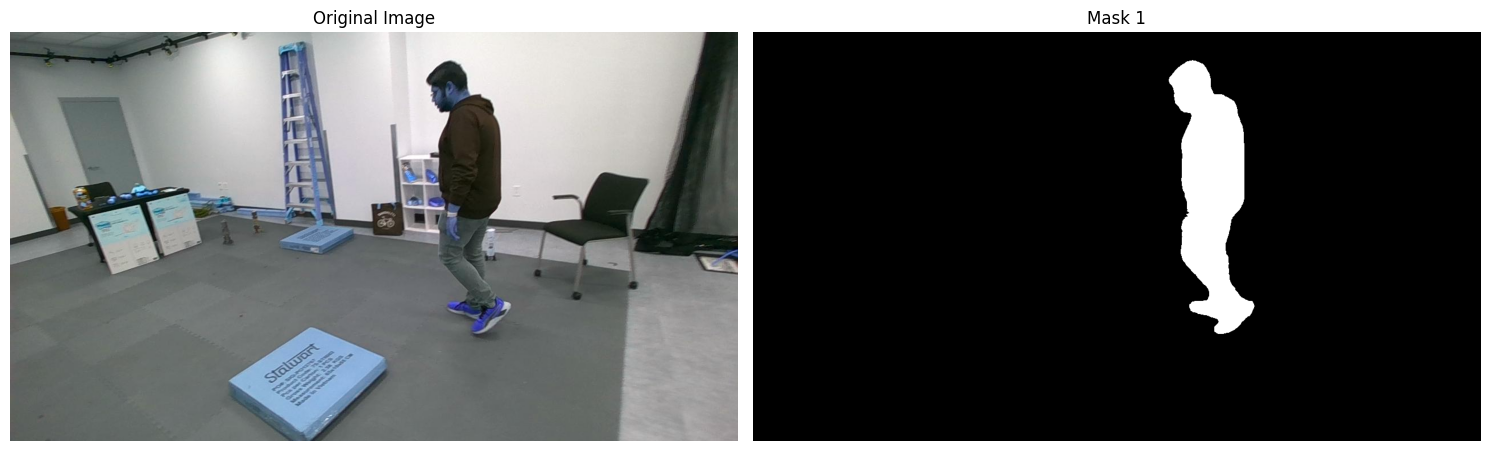

In [10]:
# Visualize the results both image and masks
def visualize_results(image, masks):
    """
    Visualize the image and its corresponding masks.
    
    Args:
        image: Input image (numpy array)
        masks: List of binary masks (numpy arrays)
    """
    # Convert image to RGB if it's in BGR format
    if image.shape[2] == 3:
        image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)
    
    # Create a figure with subplots
    num_masks = len(masks)
    fig, axes = plt.subplots(1, num_masks + 1, figsize=(15, 5))
    
    # Show the original image
    axes[0].imshow(image)
    axes[0].set_title("Original Image")
    axes[0].axis("off")
    
    # Show each mask
    for i in range(num_masks):
        # Handle masks with shape (1, H, W)
        if masks[i].ndim == 3 and masks[i].shape[0] == 1:
            mask_to_display = masks[i][0]
        else:
            mask_to_display = masks[i]
            
        axes[i + 1].imshow(mask_to_display, cmap="gray")
        axes[i + 1].set_title(f"Mask {i + 1}")
        axes[i + 1].axis("off")
    
    plt.tight_layout()
    plt.show()

    
import cv2
# Load an image from the temp folder
image_path = os.path.join(temp_folder, sorted(os.listdir(temp_folder))[0])
image = cv2.imread(image_path)
if image is None:
    raise FileNotFoundError(f"Image not found at {image_path}")
image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)  # Convert to RGB if needed

# Get frame index from the filename
frame_filename = sorted(os.listdir(temp_folder))[0]
frame_idx = int(os.path.splitext(frame_filename)[0])

# Check if this frame has results
if frame_idx not in results:
    print(f"No segmentation results for frame {frame_idx}")
    print(f"Available frames: {list(results.keys())}")
else:
    # Get the masks for this frame
    frame_results = results[frame_idx]
    
    # Convert results to a list of masks
    masks = list(frame_results.values())
    
    # Visualize the image and masks
    visualize_results(image, masks)


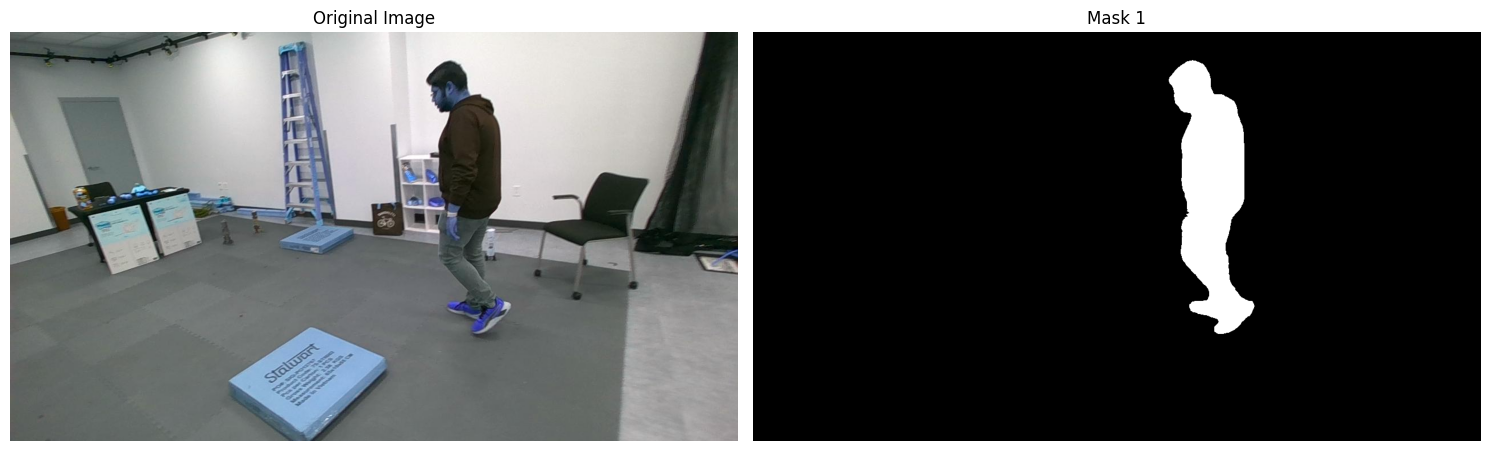

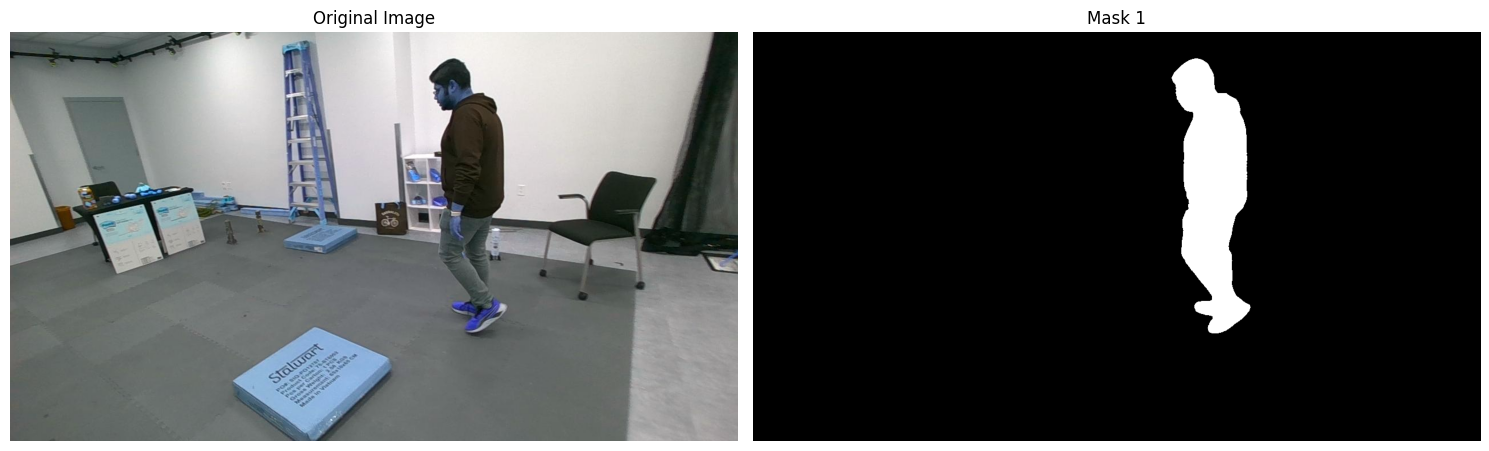

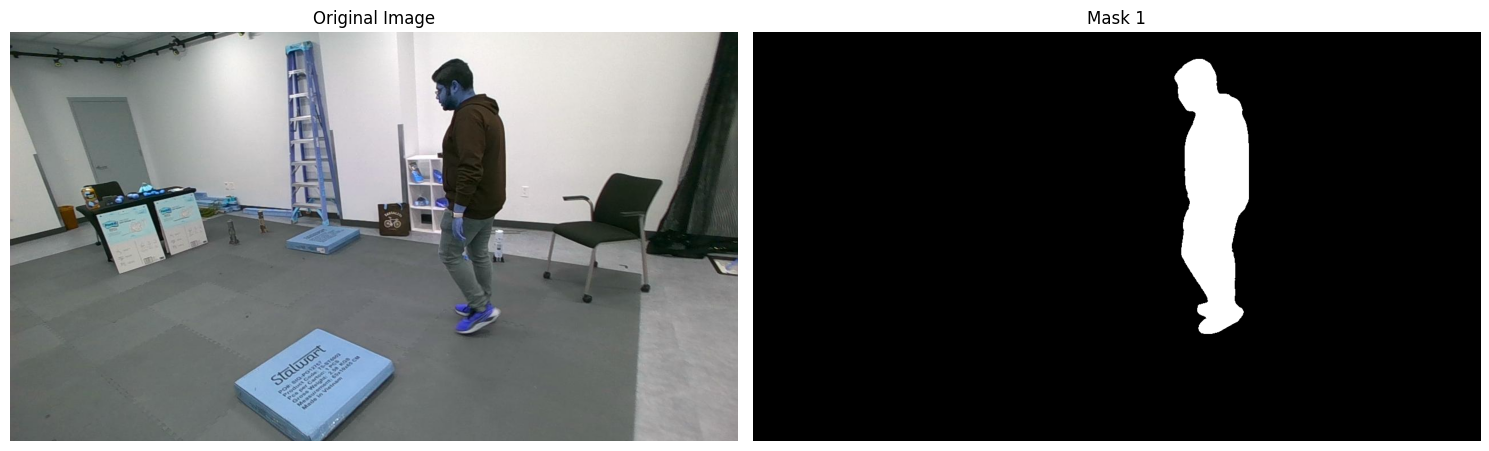

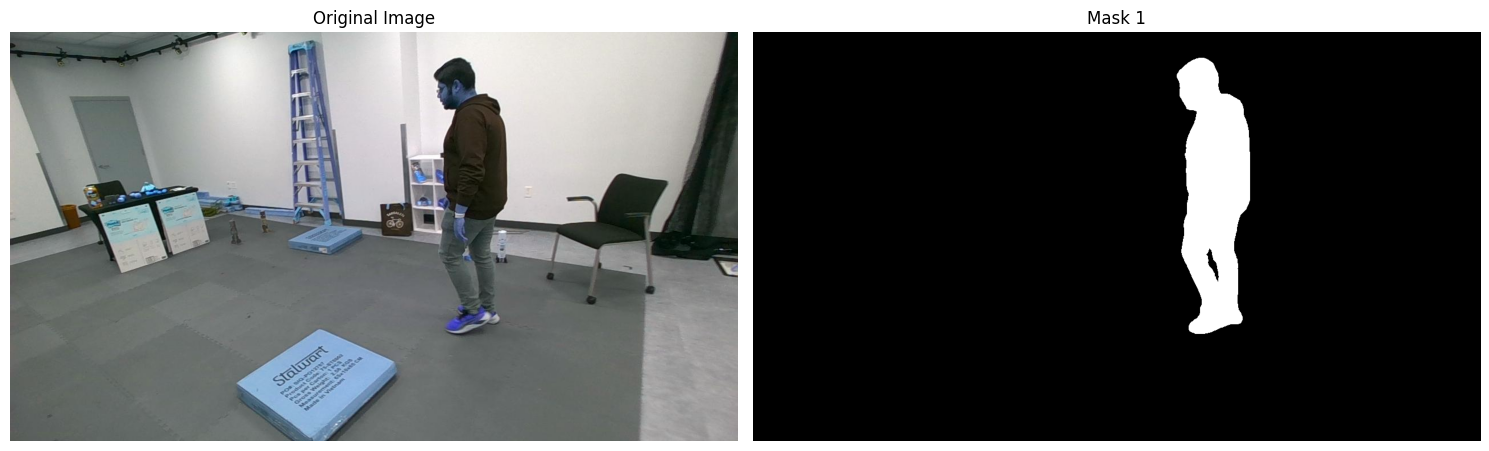

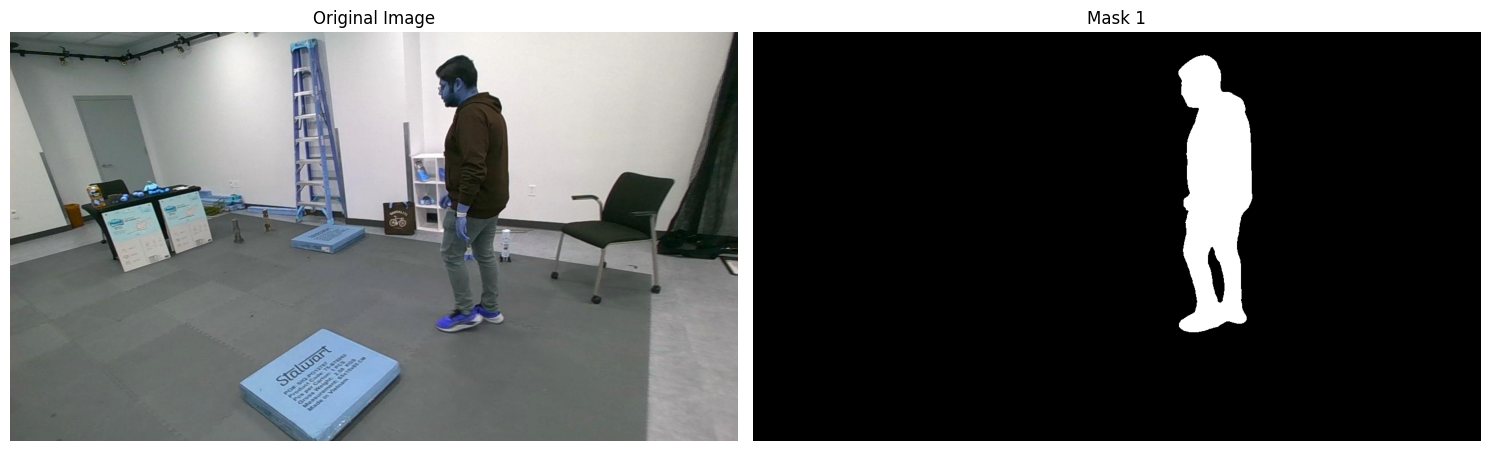

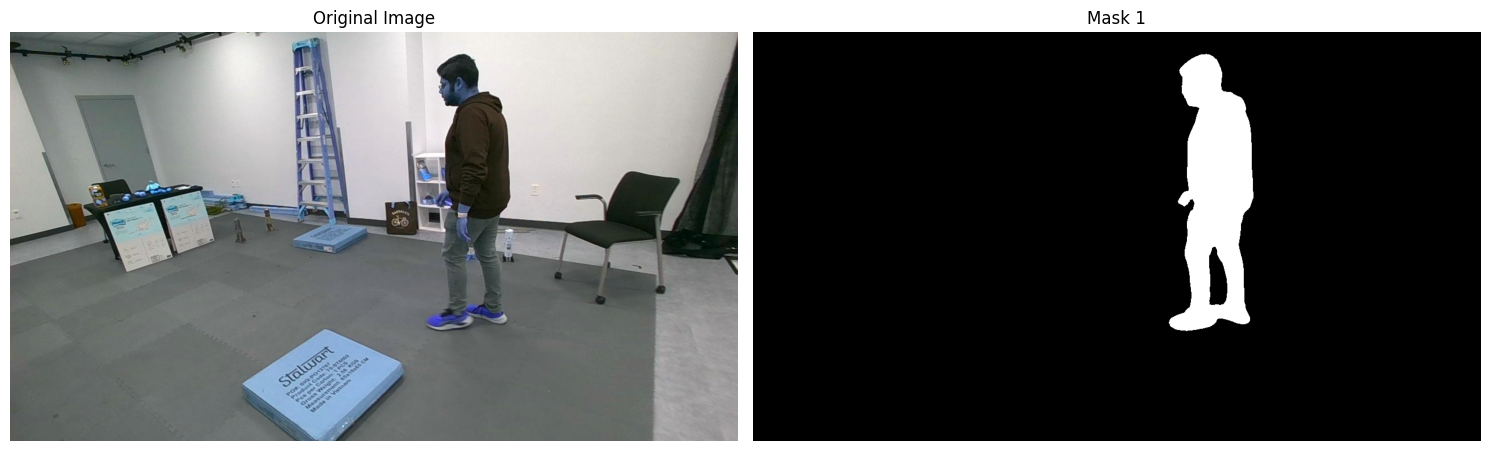

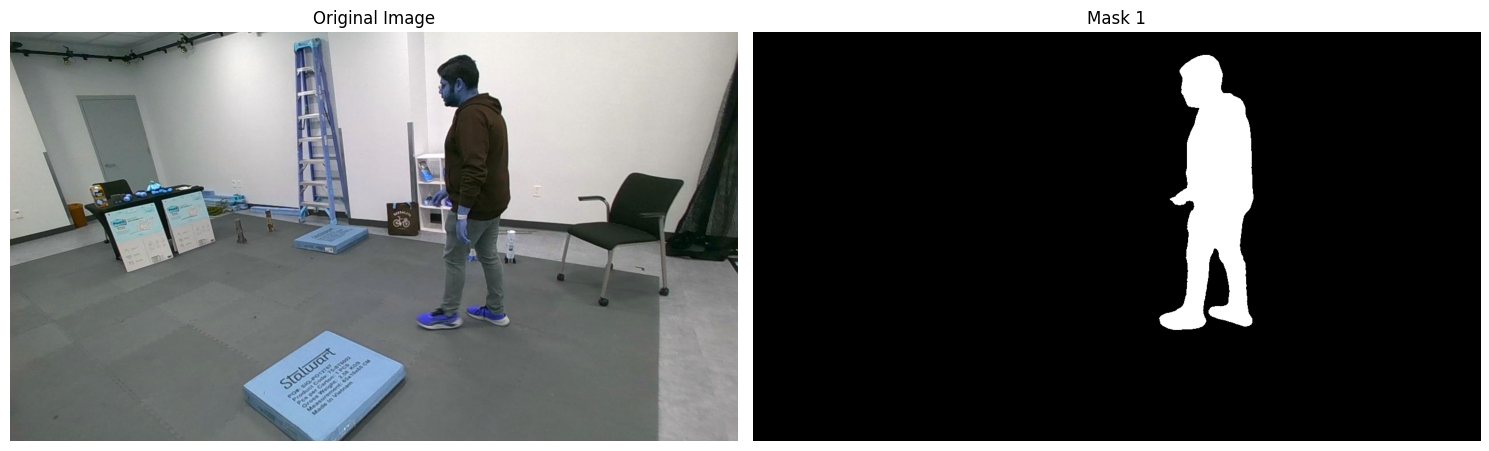

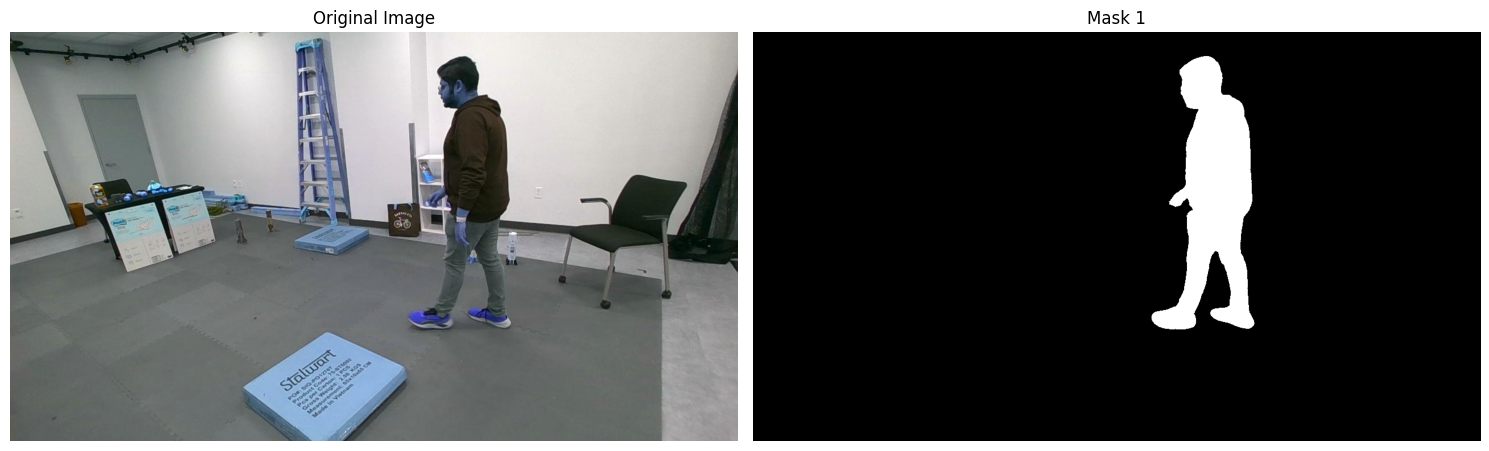

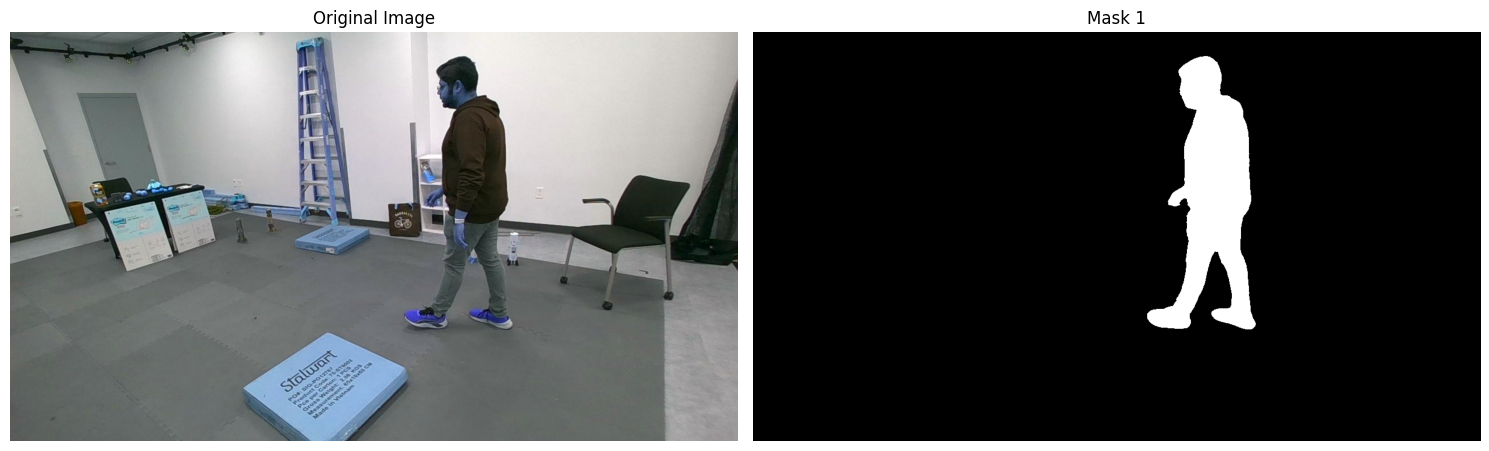

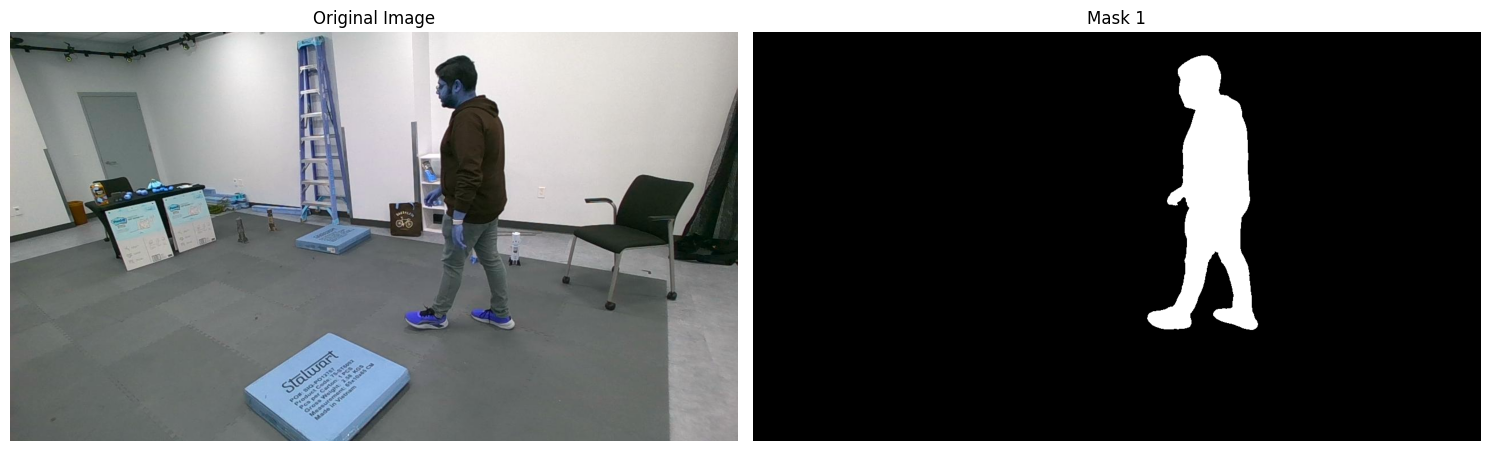

In [11]:
# Visuailize all the frames and masks
for frame_idx, frame_results in results.items():
    # Load the corresponding image
    image_path = os.path.join(temp_folder, sorted(os.listdir(temp_folder))[frame_idx])
    image = cv2.imread(image_path)
    if image is None:
        raise FileNotFoundError(f"Image not found at {image_path}")
    image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)  # Convert to RGB if needed

    # Convert results to a list of masks
    masks = list(frame_results.values())
    
    # Visualize the image and masks
    visualize_results(image, masks)

Ordered images: ['00000.jpg', '00001.jpg', '00002.jpg', '00003.jpg', '00004.jpg', '00005.jpg', '00006.jpg', '00007.jpg', '00008.jpg', '00009.jpg', '00010.jpg', '00011.jpg', '00012.jpg', '00013.jpg', '00014.jpg', '00015.jpg', '00016.jpg', '00017.jpg', '00018.jpg', '00019.jpg', '00020.jpg', '00021.jpg', '00022.jpg', '00023.jpg', '00024.jpg', '00025.jpg', '00026.jpg', '00027.jpg', '00028.jpg', '00029.jpg', '00030.jpg', '00031.jpg', '00032.jpg', '00033.jpg', '00034.jpg', '00035.jpg', '00036.jpg', '00037.jpg', '00038.jpg', '00039.jpg', '00040.jpg', '00041.jpg', '00042.jpg', '00043.jpg', '00044.jpg', '00045.jpg', '00046.jpg', '00047.jpg', '00048.jpg', '00049.jpg', '00050.jpg', '00051.jpg', '00052.jpg', '00053.jpg', '00054.jpg', '00055.jpg', '00056.jpg', '00057.jpg', '00058.jpg', '00059.jpg', '00060.jpg', '00061.jpg', '00062.jpg', '00063.jpg', '00064.jpg', '00065.jpg', '00066.jpg', '00067.jpg', '00068.jpg', '00069.jpg', '00070.jpg', '00071.jpg', '00072.jpg', '00073.jpg', '00074.jpg', '00075.j

propagate in video: 100%|██████████| 3/3 [00:00<00:00, 12.19it/s]


Updated results after new frames: {0: {1: array([[[False, False, False, ..., False, False, False],
        [False, False, False, ..., False, False, False],
        [False, False, False, ..., False, False, False],
        ...,
        [False, False, False, ..., False, False, False],
        [False, False, False, ..., False, False, False],
        [False, False, False, ..., False, False, False]]])}, 1: {1: array([[[False, False, False, ..., False, False, False],
        [False, False, False, ..., False, False, False],
        [False, False, False, ..., False, False, False],
        ...,
        [False, False, False, ..., False, False, False],
        [False, False, False, ..., False, False, False],
        [False, False, False, ..., False, False, False]]])}, 2: {1: array([[[False, False, False, ..., False, False, False],
        [False, False, False, ..., False, False, False],
        [False, False, False, ..., False, False, False],
        ...,
        [False, False, False, ..., False, 

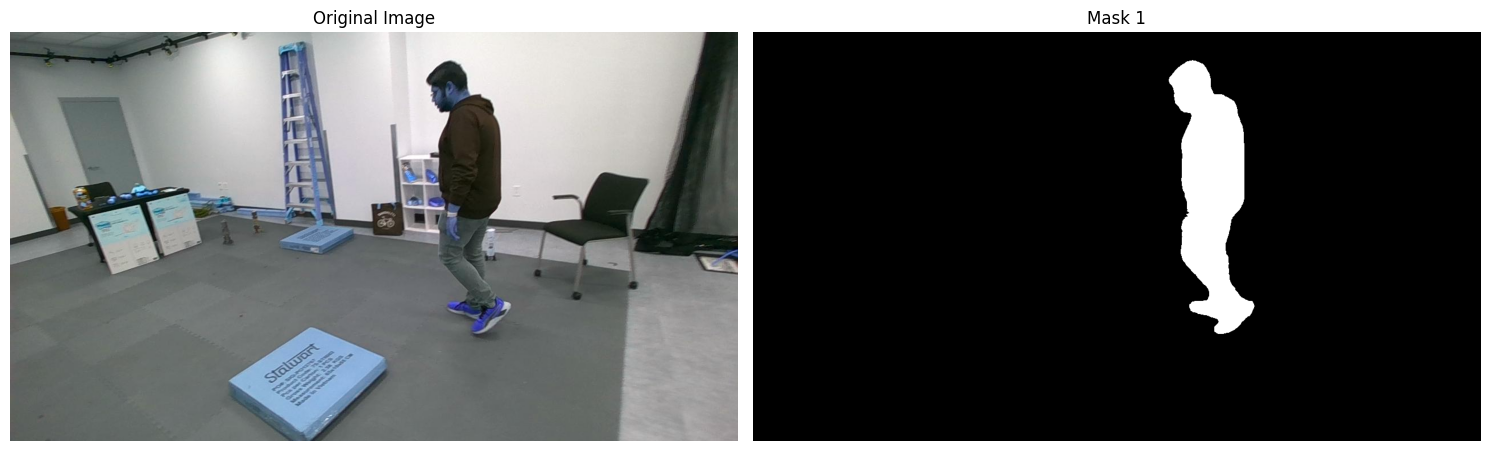

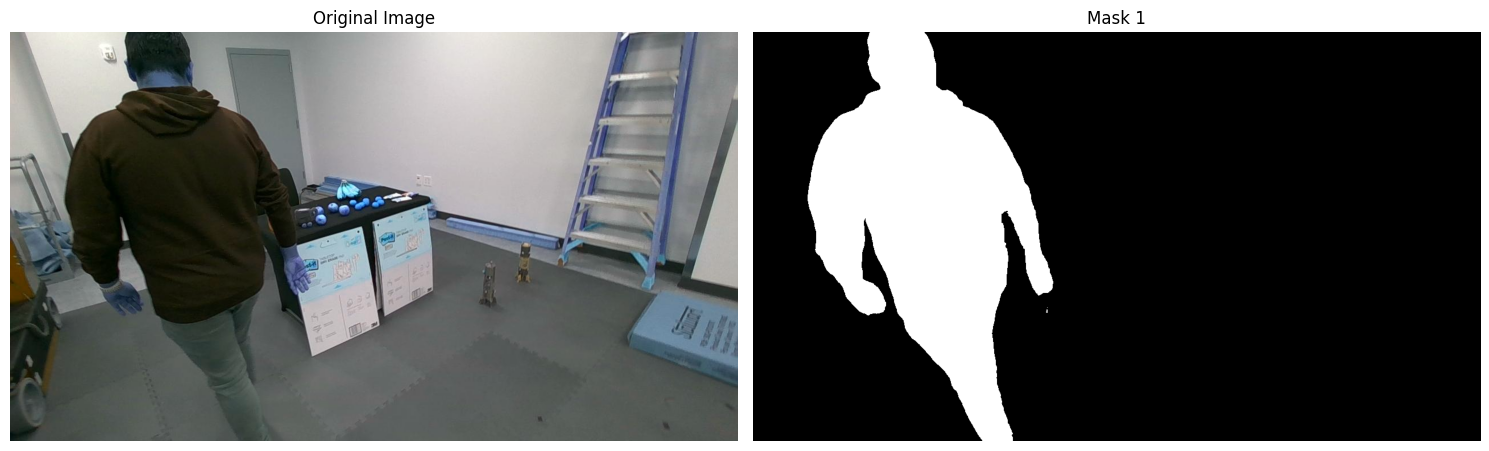

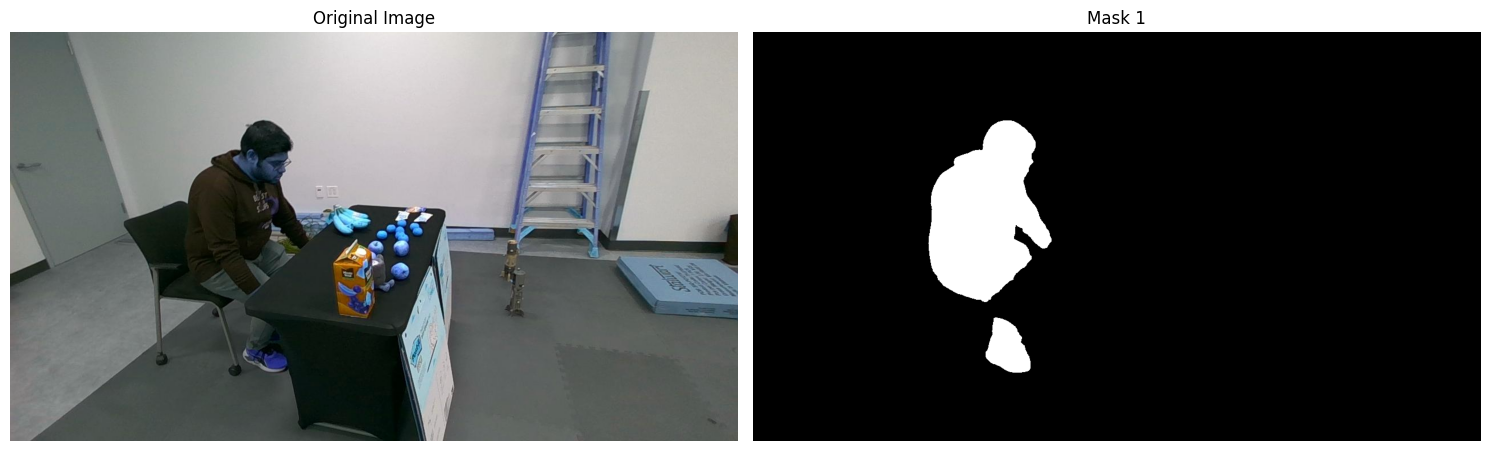

In [12]:
# Now, update the streamer with new frames - from frams 50-60
start_idx = 180
end_idx = 360
# Also include the old frame 0 
frames_ids = [start_idx, end_idx]
frames_ids = [0] + frames_ids
temp_folder = create_temp_symlink_folder_from_list_of_ids(path, frames_ids)
updated_frames = get_sam2_streamer_frames_from_sym_link(temp_folder)
print(f"Updated frames: {updated_frames}")
updated_prompts = initialize_sam2_streamer_frames_prompts(updated_frames)
print(f"Updated prompts: {updated_prompts}")
# No prompts for the new frames
updated_results = streamer.update_symlinks(updated_frames, updated_prompts)
print(f"Updated results after new frames: {updated_results}")
# Visualize the updated results
for frame_idx, frame_results in updated_results.items():
    # Load the corresponding image
    image_path = os.path.join(temp_folder, sorted(os.listdir(temp_folder))[frame_idx])
    image = cv2.imread(image_path)
    if image is None:
        raise FileNotFoundError(f"Image not found at {image_path}")
    image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)  # Convert to RGB if needed

    # Convert results to a list of masks
    masks = list(frame_results.values())
    
    # Visualize the image and masks
    visualize_results(image, masks)
